# Archetype 8 — Base + PV + BSS + HP+HS + EV (Full Stack)

## Purpose

Computes the annual TCoE for **Archetype 8** across 3 strategies × 7 DSOs → **21 runs**.

All flexible devices are co-optimised in a single **joint annual (MI)LP**. Two binary variables per slot make the BSS part a MILP: `z_bss` (charge/discharge exclusivity) and `z_m` (import/export exclusivity). HP and EV remain LP-continuous.

| Device | Type | Key constraint |
|---|---|---|
| **BSS** 10 kWh | MILP | PV-only charging; no grid-to-BSS, no BSS-to-grid export |
| **HP + HS** | LP | heat balance, HS dynamics, closed-loop year |
| **EV** 50 kWh / 11 kW | LP | departure minimum, at-home comfort floor |

_

| Strategy | Signal |
|---|---|
| **no_flex** | greedy EV + rule-based BSS dispatch; HP follows HZ2 profile |
| **dt_flex** | spot (ct/kWh) on net site import (total E_grid − E_feedin) |
| **tcoe_flex** | split signal: base at base Arbeitspreis; HP+EV at §14a option rate, BSS PV‑only shifting, no grid charge |

**PV is split in the LP** four ways per slot: `G_PV_base`, `G_PV_qual` (covers HP+EV), `G_PV_BSS` (charges battery), `G_PV_grid` (exports). This keeps the base/qualified import split exact within the MILP — no ex-post approximation needed for `tcoe_flex`.

## Input files (`inputs/`)

| File | Content |
|---|---|
| `base_demand_h25_4500kwh_2026_15min.csv` | BDEW H25 base demand |
| `pv_kassel_10kwp_2026_15min.csv` | 10 kWp PV Kassel 2026 |
| `hp_kassel_hz2_2026_15min.csv` | HP electrical demand profile |
| `hp_hz2_parameters_kassel_2026.csv` | COP, HS sizing params (frozen) |
| `ev_profile_representative_50kwh_11kw_2026_15min.csv` | EV availability + driving demand |
| `ev_parameters_representative_50kwh_11kw_2026.csv` | EV battery parameters |
| `bss_parameters_prosumer_10kwh_2026.csv` | BSS technical parameters |
| `spot_prices_de_lu_2025_15min.csv` | Spot price (ct/kWh) |
| `dso_tariffs_residential_2026.csv` | DSO tariffs + §14a modules |
| `dso_mod3_timebands_2026.csv` | Modul 3 HT/NT/ST timebands |
| `residential_taxes_2026.csv` | German levies (pre-VAT) |

**Output**: `outputs/results_base_pv_bss_hp_ev_2026.csv`  
**Solver**: Gurobi via PuLP — annual joint MILP, time limit 600 s per solve  

**Thesis reference**: Chapter 5, Section 5.1 — Archetype 8 (Full Stack)

In [1]:
import os
import numpy as np
import pandas as pd
import pulp
from pathlib import Path

os.environ['GRB_LICENSE_FILE'] = os.path.expanduser('~/gurobi.lic')

def find_repo_root(marker='README.md'):
    p = Path('__file__').resolve().parent
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError('Repo root not found')

REPO_ROOT = find_repo_root()
INPUTS    = REPO_ROOT / 'inputs'
OUTPUTS   = REPO_ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
print(f'Repo root : {REPO_ROOT}')


Repo root : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub


## Step 1 — Load inputs and device parameters

In [2]:
# Base demand
base_demand = pd.read_csv(INPUTS / 'base_demand_h25_4500kwh_2026_15min.csv', parse_dates=['timestamp'])

# PV generation ('datetime' column in this file)
pv_df = pd.read_csv(INPUTS / 'pv_kassel_10kwp_2026_15min.csv', parse_dates=['datetime'])
pv_df = pv_df.rename(columns={'datetime': 'timestamp', 'energy_kWh': 'pv_kWh'})

# HP electrical demand profile ('datetime' column)
hp_profile = pd.read_csv(INPUTS / 'hp_kassel_hz2_2026_15min.csv', parse_dates=['datetime'])
hp_profile = hp_profile.rename(columns={'datetime': 'timestamp'})

# EV profile ('local_time' column)
ev_profile = pd.read_csv(INPUTS / 'ev_profile_representative_50kwh_11kw_2026_15min.csv', parse_dates=['local_time'])
ev_profile = ev_profile.rename(columns={'local_time': 'timestamp'})

# Spot prices
spot = pd.read_csv(INPUTS / 'spot_prices_de_lu_2025_15min.csv', parse_dates=['timestamp'])

# Merge all onto one aligned 15-min index
df = (base_demand
      .merge(pv_df[['timestamp', 'pv_kWh']], on='timestamp')
      .merge(hp_profile[['timestamp', 'energy_kWh']], on='timestamp')
      .merge(ev_profile[['timestamp', 'f_avail', 'E_EV_demand_kWh']], on='timestamp')
      .merge(spot[['timestamp', 'price_ct_kWh']], on='timestamp'))
df['price_ct_kWh'] = df['price_ct_kWh'].ffill().bfill()
n = len(df)

# HP parameters (frozen at export time)
hp_params = pd.read_csv(INPUTS / 'hp_hz2_parameters_kassel_2026.csv', index_col='parameter')['value']
COP         = float(hp_params['opt_COP_constant'])
q_loss_HS   = float(hp_params['opt_q_losses_HS_per_h'])
P_HP_max_el = float(hp_params['opt_Q_HP_max_el_kW'])
Q_HP_max_th = P_HP_max_el * COP
E_HS_max    = float(hp_params['opt_HS_capacity_hours']) * Q_HP_max_th
hp_p = {'COP': COP, 'q_loss_HS': q_loss_HS, 'Q_HP_max_th': Q_HP_max_th, 'E_HS_max': E_HS_max}

# EV parameters
ev_params = pd.read_csv(INPUTS / 'ev_parameters_representative_50kwh_11kw_2026.csv', index_col='parameter')['value']
ev_p = {k: float(v) for k, v in ev_params.items()}
E_EV_max  = ev_p['E_EV_max_kWh']
P_EV_max  = ev_p['P_EV_max_ch_kW']
eta_EV    = ev_p['eta_EV_charge']
q_loss_EV = ev_p['q_losses_EV']
E_min_dep = ev_p['E_min_departure_kWh']
E_min_home = ev_p['E_min_home_kWh']  # $E_{\min,\mathrm{home}}$ (kWh)

# BSS parameters
bss_df = pd.read_csv(INPUTS / 'bss_parameters_prosumer_10kwh_2026.csv')
bss = dict(zip(bss_df['parameter'], pd.to_numeric(bss_df['value'], errors='coerce')))
E_min_bss  = float(bss['E_min_kWh'])
E_max_bss  = float(bss['E_max_kWh'])
P_bss      = float(bss['P_BSS_charge_max_kW'])
eta_ch_bss = float(bss['eta_BSS_charge'])
eta_dis_bss= float(bss['eta_BSS_discharge'])
q_loss_bss = float(bss['q_losses_BSS_per_h'])

# Levies and tariffs
taxes       = pd.read_csv(INPUTS / 'residential_taxes_2026.csv')
TAX_PRE_VAT = float(taxes.loc[taxes['region'] == 'DE', 'Total_no_VAT_ct_kWh'].iloc[0])
dso_tariffs = pd.read_csv(INPUTS / 'dso_tariffs_residential_2026.csv')
SMART_OP_EUR = 100.0
VAT_RATE     = 0.19
dt_h         = 0.25

# Core arrays
q_base        = df['demand_kwh'].values
pv_arr        = df['pv_kWh'].values
E_hp_profile  = df['energy_kWh'].values    # HP no-flex profile (kWh/slot)
f_avail       = df['f_avail'].values
E_dem         = df['E_EV_demand_kWh'].values
spot_arr      = df['price_ct_kWh'].values
Q_heat_kWh    = E_hp_profile * COP        # thermal demand = HP_el * COP [kWh_th/slot]

print(f'T={n} | base={q_base.sum():.1f} kWh | PV={pv_arr.sum():.1f} kWh | HP={E_hp_profile.sum():.1f} kWh | EV driving={E_dem.sum():.1f} kWh')
print(f'HP params: COP={COP}, Q_HP_max_th={Q_HP_max_th:.1f} kW_th, E_HS_max={E_HS_max:.1f} kWh_th')
print(f'BSS: {E_min_bss}-{E_max_bss} kWh | {P_bss} kW | eta_ch={eta_ch_bss} | eta_dis={eta_dis_bss}')
print(f'EV: {E_EV_max} kWh | {P_EV_max} kW | E_min_dep={E_min_dep} kWh')
print(f'Levies (pre-VAT): {TAX_PRE_VAT} ct/kWh | Smart op: {SMART_OP_EUR} EUR/yr')


T=35040 | base=4500.0 kWh | PV=11749.3 kWh | HP=4499.1 kWh | EV driving=2610.0 kWh
HP params: COP=3.2, Q_HP_max_th=20.0 kW_th, E_HS_max=40.0 kWh_th
BSS: 2.0-9.0 kWh | 10.0 kW | eta_ch=0.9746794344808964 | eta_dis=0.9746794344808964
EV: 50.0 kWh | 11.0 kW | E_min_dep=25.0 kWh
Levies (pre-VAT): 6.64 ct/kWh | Smart op: 100.0 EUR/yr


## Step 2 — No-flex dispatch

The no-flex baseline runs three independent rule-based dispatches:
- **EV**: greedy charging (full power when home and SoC < E_min_dep)
- **BSS**: PV-first rule (surplus charges BSS; deficit discharges BSS; no grid charging)
- **HP**: follows the HZ2 reference profile exactly (no shift)

These are combined to get total site import/export.

In [3]:
# Greedy EV no-flex (same logic as A5/A7)
soc_ev_nf  = np.zeros(n + 1)
soc_ev_nf[0] = E_min_home
P_ev_nf    = np.zeros(n)
for t in range(n):
    if f_avail[t] > 0.5 and soc_ev_nf[t] < E_min_dep:  # home AND below departure threshold
        P_ev_nf[t] = P_EV_max
    soc_ev_nf[t+1] = np.clip(
        (1 - q_loss_EV * dt_h) * soc_ev_nf[t] + eta_EV * P_ev_nf[t] * dt_h - E_dem[t],
        0, E_EV_max)
E_ev_nf = P_ev_nf * dt_h / eta_EV   # grid import for EV [kWh/slot]

# Total demand seen by BSS dispatch (base + HP profile + EV grid import)
demand_total_nf = q_base + E_hp_profile + E_ev_nf

# Rule-based BSS dispatch (PV surplus charges; deficit discharges; no grid charging)
E_grid_nf   = np.zeros(n)
E_feedin_nf = np.zeros(n)
bss_dis_nf  = np.zeros(n)   # BSS discharge per slot (needed for billing split)
E_bss_nf    = E_min_bss   # start at minimum SoC
for i in range(n):
    demand = demand_total_nf[i]
    pv     = pv_arr[i]
    E_bss_nf = max(E_min_bss, E_bss_nf * (1 - q_loss_bss * dt_h))  # standby loss
    surplus  = pv - demand
    if surplus > 1e-9:  # PV exceeds demand: charge BSS or feed in
        take = min(surplus, P_bss * dt_h, (E_max_bss - E_bss_nf) / eta_ch_bss)
        E_bss_nf       = min(E_max_bss, E_bss_nf + eta_ch_bss * take)
        E_feedin_nf[i] = surplus - take
    else:               # deficit: discharge BSS or import from grid
        deficit = -surplus
        give    = min(deficit, P_bss * dt_h, (E_bss_nf - E_min_bss) * eta_dis_bss)
        E_bss_nf      = max(E_min_bss, E_bss_nf - give / eta_dis_bss)
        E_grid_nf[i]  = deficit - give
        bss_dis_nf[i] = give   # record how much the BSS discharged this slot

# Split for billing: base-first PV+BSS allocation.
# BSS discharge is treated as covering base load first (same priority as PV);
# only the remainder reduces qualified (HP+EV) imports. This mirrors the MILP's
# E_disb/E_disq split and ensures E_grid_base + E_grid_qual == E_grid exactly.
pv_to_base_nf  = np.minimum(pv_arr, q_base)
bss_to_base_nf = np.minimum(bss_dis_nf, np.maximum(0.0, q_base - pv_to_base_nf))
E_grid_base_nf = np.maximum(0.0, q_base - pv_to_base_nf - bss_to_base_nf)
E_grid_qual_nf = E_grid_nf - E_grid_base_nf   # residual: remainder from qualified loads

print(f'no_flex: grid import {E_grid_nf.sum():.1f} kWh | feed-in {E_feedin_nf.sum():.1f} kWh')
print(f'         base import {E_grid_base_nf.sum():.1f} kWh | qual import {E_grid_qual_nf.sum():.1f} kWh')


no_flex: grid import 8331.0 kWh | feed-in 7699.2 kWh
         base import 1923.3 kWh | qual import 6407.7 kWh


## Step 3 — Joint (MI)LP solver

The full-stack solver co-optimises BSS, HP and EV simultaneously in one MILP per strategy.

**PV split variables** (`G_PV_base`, `G_PV_qual`, `G_PV_BSS`, `G_PV_grid`) make the base/qualified import split exact within the optimisation. 

**BSS binary variables:**
- `z_bss[t]`: charge/discharge exclusivity (1 = discharge, 0 = charge)
- `z_m[t]`: import/export exclusivity (1 = import, 0 = export)

**HP+HS and EV** remain LP-continuous (no binaries needed for those subsystems).

In [4]:
def solve_full_stack(q_base, pv_kWh, Q_heat_kWh, f_avail, E_dem,
                     spot_ct, hp_p, ev_p, bss, strategy,
                     c_base=None, c_qual=None, time_limit_s=600, debug=None):
    """Joint annual (MI)LP for Base + PV + BSS + HP+HS + EV.

    Returns (E_grid, E_feedin, E_hp, E_ev, E_grid_base, E_grid_qual).
    All arrays are kWh/slot length T.
    Returns (None,...) tuple on solver failure.

    Strategy signals:
    - dt_flex:   min spot * (E_grid - E_feedin)
    - tcoe_flex: min c_base*E_grid_base + c_qual*E_grid_qual - spot*E_feedin
    """
    T    = len(q_base)
    dt_h = 0.25

    # Unpack parameters
    COP_     = float(hp_p['COP'])
    q_hs     = float(hp_p['q_loss_HS'])
    Q_HP_max = float(hp_p['Q_HP_max_th'])
    E_HS_max_= float(hp_p['E_HS_max'])
    Q_dot    = Q_heat_kWh / dt_h          # [kW_th] instantaneous thermal demand

    eta_ev_  = float(ev_p['eta_EV_charge'])
    q_ev     = float(ev_p['q_losses_EV'])
    P_ev_max = float(ev_p['P_EV_max_ch_kW'])
    E_ev_max = float(ev_p['E_EV_max_kWh'])
    E_ev_0   = float(ev_p['E_min_home_kWh'])
    E_dep    = float(ev_p['E_min_departure_kWh'])

    E_bss_min = float(bss['E_min_kWh'])
    E_bss_max = float(bss['E_max_kWh'])
    P_bss_max = float(bss['P_BSS_charge_max_kW'])
    eta_ch_   = float(bss['eta_BSS_charge'])
    eta_dis_  = float(bss['eta_BSS_discharge'])
    q_bss_    = float(bss['q_losses_BSS_per_h'])

    e_ch_max  = P_bss_max * dt_h
    M_big     = float(max(q_base.max(), 1) + max(pv_kWh.max(), 1) + P_bss_max * dt_h + 100)

    prob = pulp.LpProblem('full_stack', pulp.LpMinimize)

    # PV split (kWh/slot): grid export + base self-consumption + qual self-consumption + BSS charge
    G_PV_grid = [pulp.LpVariable(f'Gpvg_{t}', lowBound=0) for t in range(T)]
    G_PV_base = [pulp.LpVariable(f'Gpvb_{t}', lowBound=0) for t in range(T)]
    G_PV_qual = [pulp.LpVariable(f'Gpvq_{t}', lowBound=0) for t in range(T)]
    G_PV_BSS  = [pulp.LpVariable(f'GpvB_{t}', lowBound=0) for t in range(T)]

    # Grid import split: base (always at base_ap) + qualified (HP+EV, at §14a rate)
    E_grid_base = [pulp.LpVariable(f'Egb_{t}', lowBound=0) for t in range(T)]
    E_grid_qual = [pulp.LpVariable(f'Egq_{t}', lowBound=0) for t in range(T)]
    E_grid      = [pulp.LpVariable(f'Eg_{t}',  lowBound=0) for t in range(T)]
    E_feedin    = [pulp.LpVariable(f'Ef_{t}',  lowBound=0) for t in range(T)]

    # BSS state and discharge split (kWh/slot)
    E_bss  = [pulp.LpVariable(f'Eb_{t}', lowBound=E_bss_min, upBound=E_bss_max) for t in range(T+1)]
    E_disb = [pulp.LpVariable(f'Edb_{t}', lowBound=0) for t in range(T)]  # BSS discharge to base
    E_disq = [pulp.LpVariable(f'Edq_{t}', lowBound=0) for t in range(T)]  # BSS discharge to qual
    z_bss  = [pulp.LpVariable(f'zb_{t}', cat='Binary') for t in range(T)]  # 1=discharge, 0=charge
    z_m    = [pulp.LpVariable(f'zm_{t}', cat='Binary') for t in range(T)]  # 1=import, 0=export

    # HP+HS variables
    Q_HP_bld = [pulp.LpVariable(f'Qhb_{t}', lowBound=0) for t in range(T)]  # HP -> building [kW_th]
    Q_HP_HS  = [pulp.LpVariable(f'QhH_{t}', lowBound=0) for t in range(T)]  # HP -> HS [kW_th]
    Q_HS_bld = [pulp.LpVariable(f'QHb_{t}', lowBound=0) for t in range(T)]  # HS -> building [kW_th]
    P_HP_el  = [pulp.LpVariable(f'Php_{t}', lowBound=0) for t in range(T)]  # HP electric power [kW]
    E_HS     = [pulp.LpVariable(f'EHS_{t}', lowBound=0, upBound=E_HS_max_) for t in range(T+1)]

    # EV variables
    P_ev = [pulp.LpVariable(f'Pev_{t}', lowBound=0, upBound=P_ev_max * float(f_avail[t]))
            for t in range(T)]
    E_ev = [pulp.LpVariable(f'Eev_{t}', lowBound=0, upBound=E_ev_max) for t in range(T+1)]

    # Initial / boundary conditions
    prob += E_bss[0] == E_bss_min    # BSS starts at minimum (conservative)
    prob += E_HS[0]  == E_HS[T]      # HP/HS: closed-loop year (no arbitrary init)
    prob += E_ev[0]  == E_ev_0       # EV starts at comfort floor

    for t in range(T):
        gt = float(pv_kWh[t])
        qt = float(q_base[t])

        # PV balance: all generation allocated to one of four uses
        prob += G_PV_grid[t] + G_PV_base[t] + G_PV_qual[t] + G_PV_BSS[t] == gt
        prob += E_feedin[t] == G_PV_grid[t]   # only PV can be exported (no BSS-to-grid)

        # BSS charge/discharge exclusivity via Big-M
        prob += G_PV_BSS[t] <= e_ch_max * (1 - z_bss[t])           # charge only when z_bss=0
        prob += E_disb[t] + E_disq[t] <= e_ch_max * z_bss[t]        # discharge only when z_bss=1

        # BSS state dynamics
        prob += E_bss[t+1] == ((1 - q_bss_ * dt_h) * E_bss[t]
                                + q_bss_ * dt_h * E_bss_min          # loss anchor at E_min
                                + eta_ch_ * G_PV_BSS[t]
                                - (E_disb[t] + E_disq[t]) / eta_dis_)

        # HP thermal model
        prob += Q_HP_bld[t] + Q_HS_bld[t] == float(Q_dot[t])  # heat balance: meet demand every slot
        prob += E_HS[t+1] == (1 - q_hs*dt_h)*E_HS[t] + Q_HP_HS[t]*dt_h - Q_HS_bld[t]*dt_h
        prob += P_HP_el[t] * COP_ == Q_HP_bld[t] + Q_HP_HS[t]  # COP links electric to thermal
        prob += Q_HP_bld[t] + Q_HP_HS[t] <= Q_HP_max
        prob += Q_HS_bld[t] <= Q_HP_max

        # EV SoC dynamics
        prob += E_ev[t+1] == (1-q_ev*dt_h)*E_ev[t] + eta_ev_*P_ev[t]*dt_h - float(E_dem[t])
        if float(f_avail[t]) > 0.5:                           # at-home comfort floor (both boundaries)
            prob += E_ev[t]   >= E_ev_0
            prob += E_ev[t+1] >= E_ev_0

        # Electricity balance (kWh/slot)
        E_hp_site = P_HP_el[t] * dt_h
        E_ev_site = P_ev[t] * dt_h / eta_ev_
        prob += qt == G_PV_base[t] + E_disb[t] + E_grid_base[t]              # base load balance
        prob += E_hp_site + E_ev_site == G_PV_qual[t] + E_disq[t] + E_grid_qual[t]  # HP+EV balance
        prob += E_grid[t] == E_grid_base[t] + E_grid_qual[t]                 # total import

        # Import/export exclusivity (site can't simultaneously import and export)
        prob += E_grid[t]   <= M_big * z_m[t]
        prob += E_feedin[t] <= M_big * (1 - z_m[t])

    # EV departure minimum at every home->away transition
    for t in range(1, T):
        if float(f_avail[t-1]) > 0.5 and float(f_avail[t]) <= 0.5:
            prob += E_ev[t] >= E_dep

    # Objective
    if strategy == 'dt_flex':
        prob += pulp.lpSum(float(spot_ct[t]) * E_grid[t] - float(spot_ct[t]) * E_feedin[t]
                           for t in range(T))
    elif strategy == 'tcoe_flex':
        if c_base is None or c_qual is None:
            raise ValueError('tcoe_flex requires c_base and c_qual arrays')
        # Split objective: base import penalised at base+levy; qual import at §14a option+levy
        prob += pulp.lpSum(
            float(c_base[t]) * E_grid_base[t]
            + float(c_qual[t]) * E_grid_qual[t]
            - float(spot_ct[t]) * E_feedin[t]
            for t in range(T))
    else:
        raise ValueError(f'Unknown strategy: {strategy}')

    prob.solve(pulp.GUROBI(timeLimit=time_limit_s, msg=False))
    if prob.status != pulp.LpStatusOptimal:
        return (None,) * 6

    def vv(var, T_):
        return np.array([float(pulp.value(var[t]) or 0) for t in range(T_)])

    E_hp_out = vv(P_HP_el, T) * dt_h
    E_ev_out = np.array([float(pulp.value(P_ev[t]) or 0) * dt_h / eta_ev_ for t in range(T)])
    E_g   = vv(E_grid, T)
    E_f   = vv(E_feedin, T)
    E_gb  = vv(E_grid_base, T)
    E_gq  = vv(E_grid_qual, T)

    if debug is not None:
        debug.clear()
        # Core electric flows (kWh/slot)
        debug['E_grid']   = E_g
        debug['E_feedin'] = E_f
        debug['E_grid_base'] = E_gb
        debug['E_grid_qual'] = E_gq

        # PV split (kWh/slot)
        debug['G_PV_grid'] = vv(G_PV_grid, T)
        debug['G_PV_base'] = vv(G_PV_base, T)
        debug['G_PV_qual'] = vv(G_PV_qual, T)
        debug['G_PV_BSS']  = vv(G_PV_BSS,  T)

        # BSS internals (kWh)
        debug['E_bss']    = np.array([float(pulp.value(E_bss[t]) or 0) for t in range(T+1)])

        # HP/HS internals
        debug['E_HS']     = np.array([float(pulp.value(E_HS[t]) or 0) for t in range(T+1)])
        debug['Q_HP_bld'] = vv(Q_HP_bld, T)
        debug['Q_HP_HS']  = vv(Q_HP_HS,  T)
        debug['Q_HS_bld'] = vv(Q_HS_bld, T)
        debug['q_loss_HS'] = q_hs
        debug['E_HS_max']  = E_HS_max_

        # EV internals
        debug['E_ev_soc'] = np.array([float(pulp.value(E_ev[t]) or 0) for t in range(T+1)])
        debug['P_ev_kW']  = vv(P_ev, T)

    return E_g, E_f, E_hp_out, E_ev_out, E_gb, E_gq

print('solve_full_stack defined.')


solve_full_stack defined.


## Step 4 — Run strategies and QA

**§14a signal split for `tcoe_flex`:**
- `c_base = spot + base_ap + TAX` (BSS + base load; not subject to §14a reduction)
- `c_qual = spot + §14a_rate + TAX` (HP+EV grid import; varies by option)

In [5]:
MOD3_TIMEBANDS = pd.read_csv(INPUTS / 'dso_mod3_timebands_2026.csv')

def build_qual_dso_rate_mod3(ts_index, dso_name, dso_row):
    """Per-slot Modul 3 DSO rate for HP+EV (qualified) import [ct/kWh]."""
    ht, nt, st = float(dso_row['HT_ct_kWh']), float(dso_row['NT_ct_kWh']), float(dso_row['ST_ct_kWh'])
    T   = len(ts_index)
    idx = pd.to_datetime(ts_index)
    hours  = idx.dt.hour + idx.dt.minute / 60.0
    months = idx.dt.month
    is_q1q4 = (months <= 3) | (months >= 10)
    rates = np.full(T, st, dtype=float)
    def in_range(h, s, e):
        return (h >= s) & (h < e) if s <= e else (h >= s) | (h < e)
    tb = MOD3_TIMEBANDS[MOD3_TIMEBANDS['DSO'] == dso_name]
    for band, level in [('NT', nt), ('HT', ht)]:
        for _, r in tb[tb['band'] == band].iterrows():
            qg = str(r['quarter_group'])
            qm = is_q1q4 if qg == 'q1q4' else (~is_q1q4 if qg == 'q2q3' else np.ones(T, bool))
            rates[qm & in_range(hours, float(r['start_hour']), float(r['end_hour']))] = level
    return rates

ts_idx = df['timestamp']

schedules = {
    # Tuple convention: (E_grid, E_feedin, E_hp, E_ev, E_grid_base, E_grid_qual[, opt, debug])
    'no_flex':   (E_grid_nf, E_feedin_nf, E_hp_profile, E_ev_nf, E_grid_base_nf, E_grid_qual_nf),
    'dt_flex':   None,
    'tcoe_flex': {},
}

# dt_flex: minimise net spot cost on total site import
dbg_dt = {}
_res = solve_full_stack(q_base, pv_arr, Q_heat_kWh, f_avail, E_dem,
                         spot_arr, hp_p, ev_p, bss, 'dt_flex', debug=dbg_dt)
if _res[0] is not None:
    Eg, Ef, Ehp, Eev, Egb, Egq = _res
    schedules['dt_flex'] = (Eg, Ef, Ehp, Eev, Egb, Egq)
    print(f'dt_flex OK: import={Eg.sum():.1f} kWh | feed-in={Ef.sum():.1f} kWh')
else:
    schedules['dt_flex'] = schedules['no_flex']
    print('dt_flex FAILED -- using no_flex fallback')

def bill_full_stack(E_grid, E_feedin, E_gb, E_gq, dso_row, opt):
    """Full annual gross bill (EUR) for the full-stack archetype.
    Base + BSS import billed at standard Arbeitspreis; HP+EV import at §14a option rate."""
    base_ap  = float(dso_row['Arbeitspreis_ct_kWh'])
    mod1_eur = float(dso_row['Module1_rebate_EUR_year'])
    mod2_ct  = float(dso_row['Module2_ct_kWh'])
    cost_spot = (np.sum(E_grid * spot_arr) - np.sum(E_feedin * spot_arr)) / 100.0
    if opt == 'opt1':      # base+qual at same rate; annual fixed rebate
        cost_dso_vol = np.sum((E_gb + E_gq) * base_ap) / 100.0 + mod1_eur
    elif opt == 'opt2':    # qual at reduced flat rate; no rebate
        cost_dso_vol = (np.sum(E_gb * base_ap) + np.sum(E_gq * mod2_ct)) / 100.0
    else:                  # opt1+3: qual at HT/NT/ST timeband rate; annual rebate applies
        mod3_r = build_qual_dso_rate_mod3(ts_idx, str(dso_row['DSO']), dso_row)
        cost_dso_vol = (np.sum(E_gb * base_ap) + np.sum(E_gq * mod3_r)) / 100.0 + mod1_eur
    cost_lev   = np.sum(E_grid) * TAX_PRE_VAT / 100.0
    cost_fixed = float(dso_row['Grundpreis_EUR_year']) + SMART_OP_EUR
    subtotal   = cost_spot + cost_dso_vol + cost_lev + cost_fixed
    return subtotal + VAT_RATE * subtotal

# tcoe_flex: sweep three §14a options per DSO, keep cheapest
for _, dso_row in dso_tariffs.iterrows():
    dso_id  = str(dso_row['DSO'])
    base_ap = float(dso_row['Arbeitspreis_ct_kWh'])
    mod2_ct = float(dso_row['Module2_ct_kWh'])
    mod3_r  = build_qual_dso_rate_mod3(ts_idx, dso_id, dso_row)

    # c_base is identical for all options: BSS/base are not §14a controllable
    c_base_sig = spot_arr + base_ap + TAX_PRE_VAT
    c_opt1  = spot_arr + base_ap + TAX_PRE_VAT  # opt1:   standard rate for qual import
    c_opt2  = spot_arr + mod2_ct  + TAX_PRE_VAT  # opt2:   reduced flat rate
    c_opt13 = spot_arr + mod3_r   + TAX_PRE_VAT  # opt1+3: HT/NT/ST timeband

    cands = []
    for opt_name, c_qual_sig in [('opt1', c_opt1), ('opt2', c_opt2), ('opt1+3', c_opt13)]:
        dbg = {}
        _r = solve_full_stack(q_base, pv_arr, Q_heat_kWh, f_avail, E_dem,
                               spot_arr, hp_p, ev_p, bss, 'tcoe_flex',
                               c_base=c_base_sig, c_qual=c_qual_sig,
                               debug=dbg, time_limit_s=600)
        if _r[0] is None: continue
        Eg, Ef, Ehp, Eev, Egb, Egq = _r
        total = bill_full_stack(Eg, Ef, Egb, Egq, dso_row, opt_name)
        cands.append((total, Eg, Ef, Ehp, Eev, Egb, Egq, opt_name, dbg))

    if cands:
        best = min(cands, key=lambda x: x[0])
        # Store: (E_grid, E_feedin, E_hp, E_ev, E_grid_base, E_grid_qual, opt, debug)
        schedules['tcoe_flex'][dso_id] = best[1:]
    print(f'  tcoe_flex {dso_id}: best={schedules["tcoe_flex"].get(dso_id, [None]*7)[6]}')

# ── QA ────────────────────────────────────────────────────────────────────────
def _qa(tag, E_g, E_f, E_hp, E_ev, E_gb, E_gq, dbg):
    # Non-negativity: all flows must be >= 0
    for arr, name in [(E_g,'grid'),(E_f,'feedin'),(E_hp,'hp'),(E_ev,'ev'),(E_gb,'grid_base'),(E_gq,'grid_qual')]:
        assert np.nanmin(arr) >= -1e-9, f'[{tag}] negative {name}'

    # Import/export exclusivity: site cannot simultaneously import and export
    overlap = np.where((E_g > 1e-9) & (E_f > 1e-9))[0]
    assert overlap.size == 0, f'[{tag}] import+export overlap at {overlap.size} slots'

    # Import split identity: E_grid == E_grid_base + E_grid_qual
    resid = np.abs(E_g - (E_gb + E_gq))
    assert resid.max() < 1e-6, f'[{tag}] import split violated: max|resid|={resid.max():.2e}'

    # Objective sanity (quick): dt_flex should not increase spot cost vs no_flex
    if tag == 'dt_flex':
        spot_nf = float(((E_grid_nf - E_feedin_nf) * spot_arr).sum())
        spot_dt = float(((E_g - E_f) * spot_arr).sum())
        assert spot_dt <= spot_nf + 1e-6, f'[dt_flex] spot cost worse than no_flex ({spot_dt:.2f} > {spot_nf:.2f})'

    if dbg is None or not dbg:
        return

    # PV split closure + "no BSS-to-grid" policy (debug-only)
    pv_res = np.abs(np.asarray(dbg['G_PV_grid']) + np.asarray(dbg['G_PV_base']) + np.asarray(dbg['G_PV_qual']) + np.asarray(dbg['G_PV_BSS']) - pv_arr)
    assert pv_res.max() < 1e-6, f'[{tag}] PV split residual max={pv_res.max():.2e}'
    exp_res = np.abs(np.asarray(dbg['E_feedin']) - np.asarray(dbg['G_PV_grid']))
    assert exp_res.max() < 1e-6, f'[{tag}] feed-in not equal PV-grid export max={exp_res.max():.2e}'

    # HP thermal: HS bounds, periodicity, heat balance
    E_HS_ = np.asarray(dbg['E_HS'])
    assert E_HS_.min() >= -1e-8, f'[{tag}] HS energy negative'
    assert E_HS_.max() <= dbg['E_HS_max'] + 1e-6, f'[{tag}] HS exceeds E_HS_max'
    assert abs(float(E_HS_[0]) - float(E_HS_[-1])) < 1e-6, f'[{tag}] HS periodicity violated'
    Q_dot_ref = Q_heat_kWh / 0.25
    hb_res = np.abs(np.asarray(dbg['Q_HP_bld']) + np.asarray(dbg['Q_HS_bld']) - Q_dot_ref)
    assert hb_res.max() < 1e-5, f'[{tag}] heat balance residual {hb_res.max():.2e}'

    # EV SoC: bounds and departure minimum
    soc = np.asarray(dbg['E_ev_soc'])
    assert soc.min() >= -1e-6, f'[{tag}] EV SoC < 0'
    assert soc.max() <= E_EV_max + 1e-6, f'[{tag}] EV SoC > E_max'
    for t in range(1, n):
        if float(f_avail[t-1]) > 0.5 and float(f_avail[t]) <= 0.5:
            assert soc[t] >= E_min_dep - 1e-6, f'[{tag}] departure min violated at t={t}'

    # BSS: bounds
    bss_s = np.asarray(dbg['E_bss'])
    assert bss_s.min() >= E_min_bss - 1e-8, f'[{tag}] BSS below E_min'
    assert bss_s.max() <= E_max_bss + 1e-6, f'[{tag}] BSS above E_max'

# Profile alignment: E_dem > 0 only when EV is away
idx_bad = np.where((E_dem > 1e-9) & (f_avail > 0.5))[0]
assert idx_bad.size == 0, f'Profile misalignment at {idx_bad.size} slots'

_qa('no_flex', E_grid_nf, E_feedin_nf, E_hp_profile, E_ev_nf, E_grid_base_nf, E_grid_qual_nf, None)
_qa('dt_flex', *[np.asarray(x) for x in schedules['dt_flex']], dbg_dt)
for _dso, _v in schedules['tcoe_flex'].items():
    # _v = (E_grid, E_feedin, E_hp, E_ev, E_grid_base, E_grid_qual, opt, debug)
    _qa(f'tcoe_flex/{_dso}/{_v[6]}',
        np.asarray(_v[0]), np.asarray(_v[1]), np.asarray(_v[2]),
        np.asarray(_v[3]), np.asarray(_v[4]), np.asarray(_v[5]), _v[7])

print('QA passed: non-negativity, import/export exclusivity, import split, HP thermal, EV SoC, BSS bounds.')


Set parameter Username
Set parameter LicenseID to value 2795594
Academic license - for non-commercial use only - expires 2027-03-22
dt_flex OK: import=9173.8 kWh | feed-in=8405.1 kWh
  tcoe_flex Westnetz: best=opt1+3
  tcoe_flex Bayernwerk: best=opt1+3
  tcoe_flex E.DIS: best=opt1+3
  tcoe_flex Netze BW: best=opt1+3
  tcoe_flex Stromnetz Berlin: best=opt1+3
  tcoe_flex SH Netz: best=opt1+3
  tcoe_flex MITNETZ STROM: best=opt1+3
QA passed: non-negativity, import/export exclusivity, import split, HP thermal, EV SoC, BSS bounds.


## Step 5 — Mini-horizon diagnostic (sanity plot)

This 2-day zoom plot is meant to build fast intuition and confidence that the joint model closes properly:
- PV split sums to PV generation
- no simultaneous import + export
- base/qualified import split behaves as expected
- storage states and device schedules look plausible


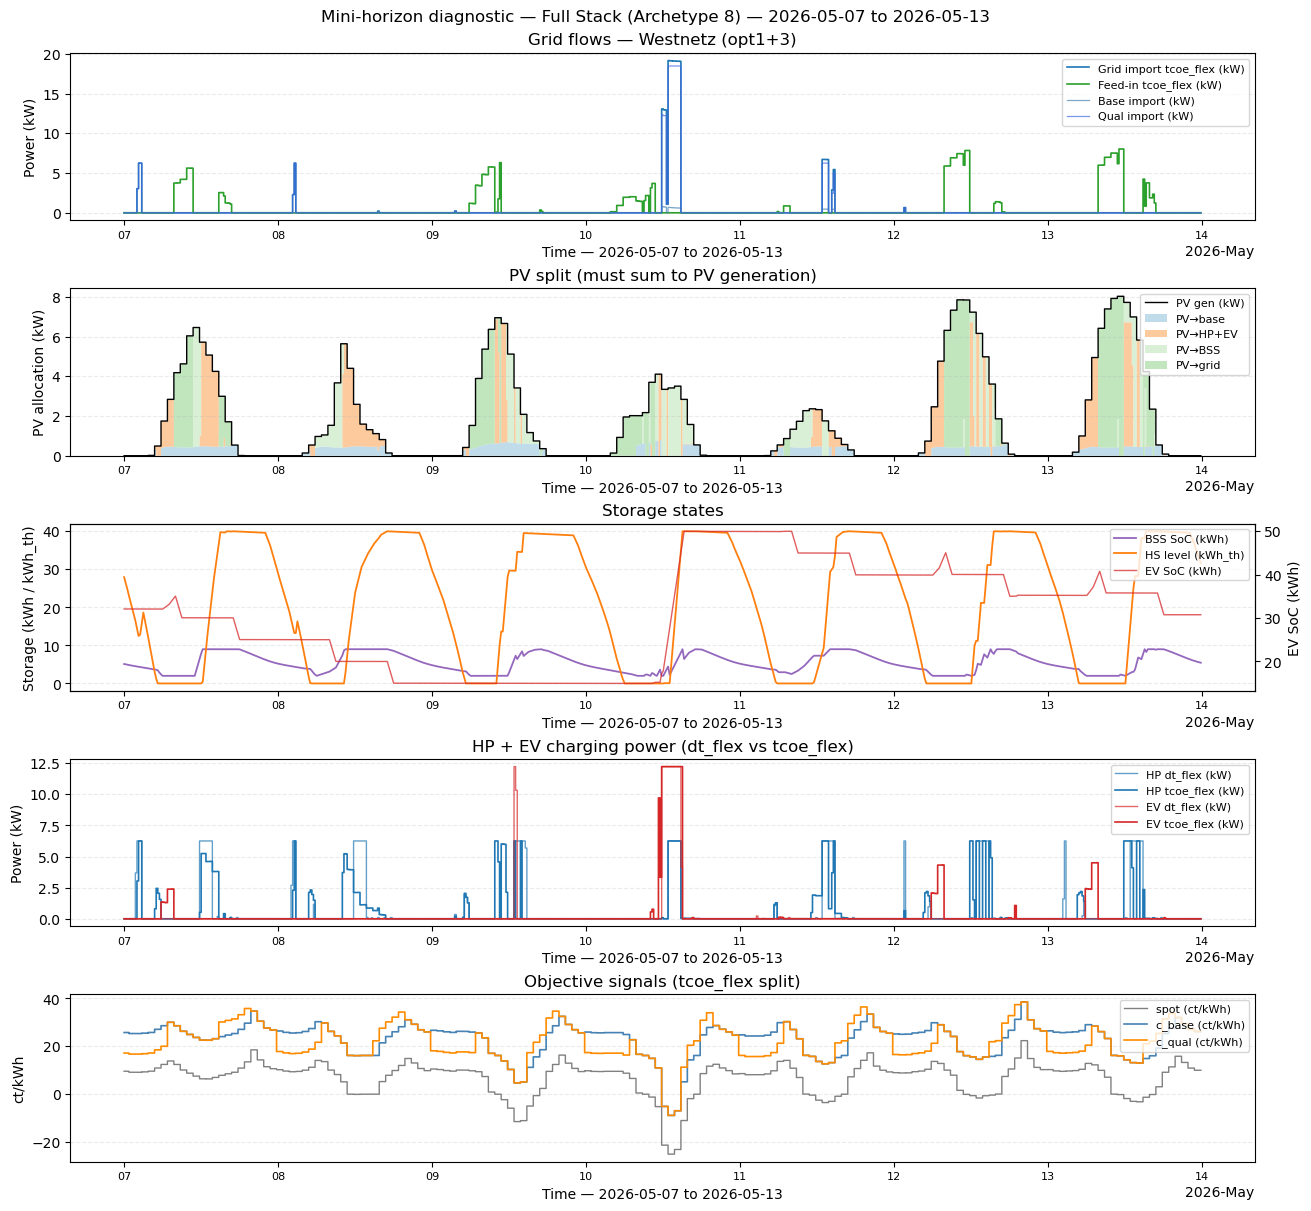

Horizon sums (2 days):
  PV gen      : 293.25 kWh
  PV split sum: 293.25 kWh
  Import      : 63.29 kWh  |  Feed-in: 108.46 kWh
  Base/Qual   : 2.54 / 60.75 kWh


In [6]:
# ── Mini-horizon diagnostic plot (1–2 days) ───────────────────────────────────
# Goal: visually confirm PV split, grid import/export exclusivity, and device scheduling.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter

REF_DSO = 'Westnetz' if 'Westnetz' in schedules['tcoe_flex'] else next(iter(schedules['tcoe_flex']))
opt_tc  = schedules['tcoe_flex'][REF_DSO][6]
dbg_tc  = schedules['tcoe_flex'][REF_DSO][7]

E_grid_tc   = np.asarray(schedules['tcoe_flex'][REF_DSO][0], dtype=float)
E_feedin_tc = np.asarray(schedules['tcoe_flex'][REF_DSO][1], dtype=float)
E_hp_tc     = np.asarray(schedules['tcoe_flex'][REF_DSO][2], dtype=float)
E_ev_tc     = np.asarray(schedules['tcoe_flex'][REF_DSO][3], dtype=float)
E_gb_tc     = np.asarray(schedules['tcoe_flex'][REF_DSO][4], dtype=float)
E_gq_tc     = np.asarray(schedules['tcoe_flex'][REF_DSO][5], dtype=float)

E_grid_dt, E_feedin_dt, E_hp_dt, E_ev_dt, E_gb_dt, E_gq_dt = [np.asarray(x, dtype=float) for x in schedules['dt_flex']]

# Choose a representative week with BOTH low and high PV within the window.
# Heuristic: pick the 7-day window with the largest PV daily range (max-min).
ts = pd.to_datetime(df['timestamp'])
pv_daily = pd.Series(pv_arr, index=ts).resample('D').sum().sort_index()

pv_range_7d = pv_daily.rolling(7).apply(lambda a: float(a.max() - a.min()), raw=False)
end_day = pv_range_7d.idxmax().floor('D')
start = end_day - pd.Timedelta(days=6)
end   = end_day + pd.Timedelta(days=1)
mask  = (ts >= start) & (ts < end)
x = ts[mask]

# Human-readable horizon label
horizon_label = f"{start.date()} to {(end - pd.Timedelta(days=1)).date()}"  # 7 days

# Build price signals used in the objective (tcoe_flex split) for the reference DSO
row = dso_tariffs.loc[dso_tariffs['DSO'] == REF_DSO].iloc[0]
base_ap = float(row['Arbeitspreis_ct_kWh'])
mod2_ct = float(row['Module2_ct_kWh'])

c_base = spot_arr + base_ap + TAX_PRE_VAT
if opt_tc == 'opt1':
    c_qual = spot_arr + base_ap + TAX_PRE_VAT
elif opt_tc == 'opt2':
    c_qual = spot_arr + mod2_ct + TAX_PRE_VAT
else:
    c_qual = spot_arr + build_qual_dso_rate_mod3(ts, REF_DSO, row) + TAX_PRE_VAT

# Unpack debug internals
E_HS_tc = np.asarray(dbg_tc.get('E_HS', np.zeros(n+1)), dtype=float)[:-1]
E_bss_tc = np.asarray(dbg_tc.get('E_bss', np.zeros(n+1)), dtype=float)[:-1]
E_ev_soc_tc = np.asarray(dbg_tc.get('E_ev_soc', np.zeros(n+1)), dtype=float)[:-1]

Gpv_grid = np.asarray(dbg_tc.get('G_PV_grid', np.zeros(n)), dtype=float)
Gpv_base = np.asarray(dbg_tc.get('G_PV_base', np.zeros(n)), dtype=float)
Gpv_qual = np.asarray(dbg_tc.get('G_PV_qual', np.zeros(n)), dtype=float)
Gpv_bss  = np.asarray(dbg_tc.get('G_PV_BSS',  np.zeros(n)), dtype=float)

fig, axes = plt.subplots(5, 1, figsize=(13, 12), constrained_layout=True, sharex=True)

# Make each panel's time axis readable (own tick labels + xlabel)
_locator = AutoDateLocator(minticks=6, maxticks=10)
_formatter = ConciseDateFormatter(_locator)
for _ax in axes:
    _ax.xaxis.set_major_locator(_locator)
    _ax.xaxis.set_major_formatter(_formatter)
    _ax.tick_params(axis='x', labelsize=8, labelbottom=True)
    _ax.set_xlabel(f'Time — {horizon_label}')

# Panel 1: Grid import/export + split
ax = axes[0]
ax.step(x, E_grid_tc[mask]*4, where='pre', lw=1.2, color='tab:blue', label='Grid import tcoe_flex (kW)')
ax.step(x, E_feedin_tc[mask]*4, where='pre', lw=1.2, color='tab:green', label='Feed-in tcoe_flex (kW)')
ax.step(x, E_gb_tc[mask]*4, where='pre', lw=0.9, color='steelblue', alpha=0.7, label='Base import (kW)')
ax.step(x, E_gq_tc[mask]*4, where='pre', lw=0.9, color='royalblue', alpha=0.7, label='Qual import (kW)')
ax.set_ylabel('Power (kW)')
ax.set_title(f'Grid flows — {REF_DSO} ({opt_tc})')
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', ls='--', alpha=0.25)

# Panel 2: PV split
ax = axes[1]
ax.step(x, pv_arr[mask]*4, where='pre', lw=1.0, color='black', label='PV gen (kW)')
ax.stackplot(x,
             (Gpv_base[mask]*4), (Gpv_qual[mask]*4), (Gpv_bss[mask]*4), (Gpv_grid[mask]*4),
             labels=['PV→base','PV→HP+EV','PV→BSS','PV→grid'],
             colors=['#9ecae1','#fdae6b','#c7e9c0','#a1d99b'], alpha=0.65, step='pre')
ax.set_ylabel('PV allocation (kW)')
ax.set_title('PV split (must sum to PV generation)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', ls='--', alpha=0.25)

# Panel 3: Storage states (BSS + HS) and EV SoC
ax = axes[2]
ax.plot(x, E_bss_tc[mask], lw=1.3, color='tab:purple', label='BSS SoC (kWh)')
ax.plot(x, E_HS_tc[mask],  lw=1.3, color='tab:orange', label='HS level (kWh_th)')
ax2 = ax.twinx()
ax2.plot(x, E_ev_soc_tc[mask], lw=1.0, color='tab:red', alpha=0.75, label='EV SoC (kWh)')
ax.set_ylabel('Storage (kWh / kWh_th)')
ax2.set_ylabel('EV SoC (kWh)')
ax.set_title('Storage states')
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines+lines2, labels+labels2, loc='upper right', fontsize=8)
ax.grid(axis='y', ls='--', alpha=0.25)

# Panel 4: Device electric power (compare dt_flex vs tcoe_flex)
ax = axes[3]
ax.step(x, E_hp_dt[mask]*4, where='pre', lw=1.0, color='tab:blue', alpha=0.7, label='HP dt_flex (kW)')
ax.step(x, E_hp_tc[mask]*4, where='pre', lw=1.2, color='tab:blue', label='HP tcoe_flex (kW)')
ax.step(x, E_ev_dt[mask]*4, where='pre', lw=1.0, color='tab:red', alpha=0.7, label='EV dt_flex (kW)')
ax.step(x, E_ev_tc[mask]*4, where='pre', lw=1.2, color='tab:red', label='EV tcoe_flex (kW)')
ax.set_ylabel('Power (kW)')
ax.set_title('HP + EV charging power (dt_flex vs tcoe_flex)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', ls='--', alpha=0.25)

# Panel 5: Price signals
ax = axes[4]
ax.step(x, spot_arr[mask], where='pre', lw=1.0, color='grey', label='spot (ct/kWh)')
ax.step(x, c_base[mask], where='pre', lw=1.2, color='steelblue', label='c_base (ct/kWh)')
ax.step(x, c_qual[mask], where='pre', lw=1.2, color='darkorange', label='c_qual (ct/kWh)')
ax.set_ylabel('ct/kWh')
ax.set_title('Objective signals (tcoe_flex split)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', ls='--', alpha=0.25)
# (time axis formatting handled for all panels above)

fig.suptitle(f'Mini-horizon diagnostic — Full Stack (Archetype 8) — {horizon_label}')
plt.show()

# One-line numeric sanity for the plotted horizon
print('Horizon sums (2 days):')
print(f"  PV gen      : {pv_arr[mask].sum():.2f} kWh")
print(f"  PV split sum: {(Gpv_base[mask]+Gpv_qual[mask]+Gpv_bss[mask]+Gpv_grid[mask]).sum():.2f} kWh")
print(f"  Import      : {E_grid_tc[mask].sum():.2f} kWh  |  Feed-in: {E_feedin_tc[mask].sum():.2f} kWh")
print(f"  Base/Qual   : {E_gb_tc[mask].sum():.2f} / {E_gq_tc[mask].sum():.2f} kWh")


## Step 6 — Billing

In [7]:
results = []
for _, dso_row in dso_tariffs.iterrows():
    dso_id = str(dso_row['DSO'])
    for strategy in ('no_flex', 'dt_flex', 'tcoe_flex'):
        if strategy == 'tcoe_flex':
            _v = schedules['tcoe_flex'][dso_id]
            # _v = (E_grid, E_feedin, E_hp, E_ev, E_grid_base, E_grid_qual, opt, debug)
            E_g, E_f, E_hp, E_ev, E_gb, E_gq, opt = [np.asarray(_v[i]) for i in range(6)] + [_v[6]]
        else:
            E_g, E_f, E_hp, E_ev, E_gb, E_gq = [np.asarray(x) for x in schedules[strategy]]
            opt = 'opt1'

        base_ap  = float(dso_row['Arbeitspreis_ct_kWh'])
        mod1_eur = float(dso_row['Module1_rebate_EUR_year'])
        mod2_ct  = float(dso_row['Module2_ct_kWh'])
        cost_spot = (np.sum(E_g * spot_arr) - np.sum(E_f * spot_arr)) / 100.0
        if opt == 'opt1':
            cost_dso_vol = np.sum((E_gb + E_gq) * base_ap) / 100.0 + mod1_eur
            cost_mod1    = mod1_eur
        elif opt == 'opt2':
            cost_dso_vol = (np.sum(E_gb * base_ap) + np.sum(E_gq * mod2_ct)) / 100.0
            cost_mod1    = 0.0
        else:
            mod3_r = build_qual_dso_rate_mod3(ts_idx, dso_id, dso_row)
            cost_dso_vol = (np.sum(E_gb * base_ap) + np.sum(E_gq * mod3_r)) / 100.0 + mod1_eur
            cost_mod1    = mod1_eur
        cost_lev    = np.sum(E_g) * TAX_PRE_VAT / 100.0
        cost_fixed  = float(dso_row['Grundpreis_EUR_year'])
        subtotal    = cost_spot + cost_dso_vol + cost_lev + cost_fixed + SMART_OP_EUR
        vat         = VAT_RATE * subtotal
        results.append({
            'strategy': strategy, 'household_archetype': 8, 'dso_id': dso_id,
            'annual_energy_kwh'            : round(float(np.sum(E_g)), 2),
            'annual_feedin_kwh'            : round(float(np.sum(E_f)), 2),
            'cost_spot_net_eur'            : round(cost_spot,    2),
            'cost_dso_volumetric_net_eur'  : round(cost_dso_vol, 2),
            'cost_dso_fixed_net_eur'       : round(cost_fixed,   2),
            'cost_smart_operating_net_eur' : round(SMART_OP_EUR, 2),
            'cost_14a_mod1_net_eur'        : round(cost_mod1,    2),
            'cost_levies_pre_vat_eur'      : round(cost_lev,     2),
            'subtotal_net_eur'             : round(subtotal,     2),
            'vat_eur'                      : round(vat,          2),
            'total_tcoe_eur'               : round(subtotal + vat, 2),
            'billing_14a_option'           : opt,
            'optimized_14a_option'         : opt if strategy == 'tcoe_flex' else None,
        })

results = pd.DataFrame(results)
assert results['total_tcoe_eur'].notna().all(), 'NaN in total_tcoe_eur'
print(f'TCoE range: {results["total_tcoe_eur"].min():.2f} – {results["total_tcoe_eur"].max():.2f} EUR/yr')
results


TCoE range: 611.74 – 2270.68 EUR/yr


,strategy,household_archetype,dso_id,annual_energy_kwh,annual_feedin_kwh,cost_spot_net_eur,cost_dso_volumetric_net_eur,cost_dso_fixed_net_eur,cost_smart_operating_net_eur,cost_14a_mod1_net_eur,cost_levies_pre_vat_eur,subtotal_net_eur,vat_eur,total_tcoe_eur,billing_14a_option,optimized_14a_option
0,no_flex,8,Westnetz,8331.00,7699.18,519.41,655.24,80.30,100.0,-138.70,553.18,1908.14,362.55,2270.68,opt1,None
1,dt_flex,8,Westnetz,9173.78,8405.11,-130.44,735.56,80.30,100.0,-138.70,609.14,1394.56,264.97,1659.52,opt1,None
2,tcoe_flex,8,Westnetz,5430.31,4695.16,-4.51,11.06,80.30,100.0,-138.70,360.57,547.42,104.01,651.43,opt1+3,opt1+3
3,no_flex,8,Bayernwerk,8331.00,7699.18,519.41,270.04,98.55,100.0,-123.18,553.18,1541.18,292.83,1834.01,opt1,None
4,dt_flex,8,Bayernwerk,9173.78,8405.11,-130.44,309.82,98.55,100.0,-123.18,609.14,987.07,187.54,1174.61,opt1,None
5,tcoe_flex,8,Bayernwerk,5540.68,4810.49,-35.36,120.05,98.55,100.0,-123.18,367.90,651.14,123.72,774.86,opt1+3,opt1+3
6,no_flex,8,E.DIS,8331.00,7699.18,519.41,347.46,76.65,100.0,-108.25,553.18,1596.70,303.37,1900.07,opt1,None
7,dt_flex,8,E.DIS,9173.78,8405.11,-130.44,393.56,76.65,100.0,-108.25,609.14,1048.90,199.29,1248.19,opt1,None
8,tcoe_flex,8,E.DIS,5432.49,4700.61,-16.26,-7.05,76.65,100.0,-108.25,360.72,514.06,97.67,611.74,opt1+3,opt1+3
9,no_flex,8,Netze BW,8331.00,7699.18,519.41,449.88,84.00,100.0,-180.78,553.18,1706.47,324.23,2030.70,opt1,None


## Step 7 — Summary and export

In [8]:
nf = (results[results['strategy'] == 'no_flex']
      [['dso_id','cost_spot_net_eur','cost_dso_volumetric_net_eur',
        'cost_14a_mod1_net_eur','cost_dso_fixed_net_eur',
        'cost_smart_operating_net_eur','cost_levies_pre_vat_eur','vat_eur','total_tcoe_eur']]
      .set_index('dso_id')
      .rename(columns={
          'cost_spot_net_eur'            : 'Spot net (€)',
          'cost_dso_volumetric_net_eur'  : 'DSO vol (€)',
          'cost_14a_mod1_net_eur'        : '§14a rebate (€)',
          'cost_dso_fixed_net_eur'       : 'DSO fix (€)',
          'cost_smart_operating_net_eur' : 'Smart op (€)',
          'cost_levies_pre_vat_eur'      : 'Levies (€)',
          'vat_eur'                      : 'VAT (€)',
          'total_tcoe_eur'               : 'TCoE no_flex (€/yr)',
      }))
print('Table 1 — no_flex cost breakdown:')
display(nf)

piv = results.pivot_table(index='dso_id', columns='strategy', values='total_tcoe_eur', aggfunc='first')
piv = piv[['no_flex','dt_flex','tcoe_flex']]
piv.columns.name = None
piv['saving dt_flex (€/yr)']   = piv['no_flex'] - piv['dt_flex']
piv['saving tcoe_flex (€/yr)'] = piv['no_flex'] - piv['tcoe_flex']
piv = piv.rename(columns={'no_flex':'TCoE no_flex (€/yr)','dt_flex':'TCoE dt_flex (€/yr)','tcoe_flex':'TCoE tcoe_flex (€/yr)'})
print('\nTable 2 — strategy comparison:')
display(piv)

out = OUTPUTS / 'results_base_pv_bss_hp_ev_2026.csv'
results.to_csv(out, index=False)
print(f'Saved: {out}  ({len(results)} rows)')


Table 1 — no_flex cost breakdown:


,Spot net (€),DSO vol (€),§14a rebate (€),DSO fix (€),Smart op (€),Levies (€),VAT (€),TCoE no_flex (€/yr)
dso_id,,,,,,,,
Westnetz,519.41,655.24,-138.70,80.30,100.0,553.18,362.55,2270.68
Bayernwerk,519.41,270.04,-123.18,98.55,100.0,553.18,292.83,1834.01
E.DIS,519.41,347.46,-108.25,76.65,100.0,553.18,303.37,1900.07
Netze BW,519.41,449.88,-180.78,84.00,100.0,553.18,324.23,2030.70
Stromnetz Berlin,519.41,498.31,-123.18,33.36,100.0,553.18,323.81,2028.07
SH Netz,519.41,417.95,-115.23,94.90,100.0,553.18,320.23,2005.68
MITNETZ STROM,519.41,411.14,-114.55,73.00,100.0,553.18,314.78,1971.51



Table 2 — strategy comparison:


,TCoE no_flex (€/yr),TCoE dt_flex (€/yr),TCoE tcoe_flex (€/yr),saving dt_flex (€/yr),saving tcoe_flex (€/yr)
dso_id,,,,,
Bayernwerk,1834.01,1174.61,774.86,659.40,1059.15
E.DIS,1900.07,1248.19,611.74,651.88,1288.33
MITNETZ STROM,1971.51,1328.05,641.82,643.46,1329.69
Netze BW,2030.70,1399.88,805.21,630.82,1225.49
SH Netz,2005.68,1363.13,636.26,642.55,1369.42
Stromnetz Berlin,2028.07,1396.16,662.12,631.91,1365.95
Westnetz,2270.68,1659.52,651.43,611.16,1619.25


Saved: /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/outputs/results_base_pv_bss_hp_ev_2026.csv  (21 rows)
